# Improving Recommendation By Improving the Quality of Image Embeddings with Gemini

In part two "**02 - ResNet and Elasticsearch**", we saw that convolutional neural networks (CNNs) have semantic limitations: *CNN-based embeddings capture low and mid-level features such as edge, texture, and color, but they do not explicitly encode global and semantic information like Vision Language Models do.*

As illustrated in [this medium story](https://pub.towardsai.net/building-an-image-based-recommendation-system-and-search-engine-with-deep-learning-and-4bb96c4d9a64), recommendations performed with CNN-based embeddings can include semantically incorrect items. I had to apply an additional filtering step, using **Filtered $k$NN** with Elasticsearch to improve recommendation quality. 

Another way to improve recommendation quality is by using Vision Language Models to extract image embeddings: Compared to CNNs, VLMs are designed to capture semantic information.

In the [Image Embeddings with SigLIP.ipynb](./Image%20Embeddings%20with%20SigLIP.ipynb) notebook, I illustrated how SigLIP embeddings can help produce better recommendations compared to ResNet50 embeddings. This notebook leverages Gemini Embedding to explore. Let's see how it can improve recommendations.

**Prerequisities**

Before running this notebook, please ensure you have the following:

* A running Elasticsearch instance (eg ```http://localhost:9200```)
* The Elasticsearch instance has an ```items``` index with the mapping defined in part two of this repository.

To follow along, please run the first two cells of this [notebook](./../02%20-%20ResNet%20and%20Elasticsearch/src/IBRS%20and%20Search%20Engine.ipynb) from part two. This will ensure you have your Elasticsearch instance up and running with the appropriate indexed documents

In [1]:
from elasticsearch import Elasticsearch
from src.settings import DATASET_DIR, MODEL_FIELD_MAPPING
from src.utils import unzip_dataset
import os

es = Elasticsearch("http://localhost:9200")

# unzip dataset if not yet done
unzip_dataset()

/home/projects/IBRS/Image-Based-Recommendation-System/03 - Image Embeddings with VLM based models/etc/venv-03/lib/python3.12/site-packages/google/cloud/aiplatform/models.py:52: FutureWarning: Support for google-cloud-storage < 3.0.0 will be removed in a future version of google-cloud-aiplatform. Please upgrade to google-cloud-storage >= 3.0.0.
  from google.cloud.aiplatform.utils import gcs_utils


[INFO] Dataset already unzipped


## 1. Embedding Extraction with Gemini

Defining an abstract base class for embedding extraction, and concrete implementations for SigLIP and latter on for Vertex AI.

In [2]:
from dotenv import load_dotenv

# reset the GEMINI_API_KEY env variable in case it has been changed from the credential file
os.environ.pop('GEMINI_API_KEY', None)

# load env variables from the credential file: it includes the GEMINI_API_KEY env variable
_ = load_dotenv(dotenv_path=os.path.join("etc/credentials/.env"))

In [3]:
from src.embeddings import ImageEmbeddingExtractor as EmbeddingExtractorABC
from typing import List

from google import genai
from google.genai import types
from google.genai import errors

from PIL import Image

import numpy as np

class GeminiEmbeddingExtractor(EmbeddingExtractorABC):
    """Embedding extractor using Google GenAI SDK."""
    
    def __init__(
        self, 
        api_key: str = os.getenv('GEMINI_API_KEY'), 
        model_name: str = "gemini-embedding-2",
        output_dimensions = 768
    ):
        """
        Initialize the Gemini Embedding Extractor using Google GenAI SDK.
        
        Args:
            api_key: Google API key. If not provided, will use GOOGLE_API_KEY env var.
            model_name: Model name to use for embeddings. Defaulf: gemini-embedding-2
            output_dimensions: The expected dimension of the embedding vector. Default: 768
        """
        if api_key is None:
            raise ValueError("Please provide the GEMINY_API_KEY")

        self.client = genai.Client(api_key=api_key)
        self.model_name = model_name
        self.output_dimensions = output_dimensions
        
    def extract_embeddings(self, image_paths: List[str]) -> np.ndarray:
        """
        Extract embeddings for a batch of image paths using Google GenAI.
        
        Args:
            image_paths: List of file paths to images
            
        Returns:
            numpy array of embeddings with shape (num_images, output_dimensions)
        """

        # load images from paths
        images = [Image.open(path).convert("RGB") for path in image_paths]
        
        # call client.models.embed_content with RGB image data
        response = self.client.models.embed_content(
            model=self.model_name,
            contents=images,
            config={
                'output_dimensionality': self.output_dimensions
            }
        )
        
        # aggregate the results
        embeddings = [emb.values for emb in response.embeddings]  
        return np.array(embeddings)

More on embeddings API with Gemini Here: 
* https://ai.google.dev/gemini-api/docs/embeddings#embed-images
* https://googleapis.github.io/python-genai/

### Test the Gemini Embedding Extractor

In [4]:
# create an instance of the Gemini Embedding Extractor
gemini_extractor = GeminiEmbeddingExtractor()

In [5]:
# set test image, you can use any image paths
test_paths = ["/home/projects/IBRS/Image-Based-Recommendation-System/etc/dataset/img1.jpg"]

# extract embeddings of the test image and display its shape
embeddings = gemini_extractor.extract_embeddings(test_paths)
np.shape(embeddings)

(1, 768)

## 2. Extract All Embeddings and Update ES
### 2.1. Update the Elasticsearch Index Mapping

In [6]:
from src.elastic import update_index_mapping

gemini_field = MODEL_FIELD_MAPPING.get("gemini")

# define the new attribute for the siglip embedding vector
new_mapping_properties = {
    "properties": {
        gemini_field: { 
            "type": "dense_vector",
            "dims": 768,
            "index": True,
            "similarity": "cosine"
        }
    }
}

update_index_mapping(es, index_name="items", body=new_mapping_properties)

[INFO] Index 'items' mapping updated.


In [7]:
# check that the mapping has been updated
es.indices.get_mapping(index="items")

ObjectApiResponse({'items': {'mappings': {'properties': {'ID': {'type': 'integer'}, 'category': {'type': 'keyword'}, 'imPath': {'type': 'keyword'}, 'image_features': {'type': 'dense_vector', 'dims': 2048, 'index': True, 'similarity': 'cosine', 'index_options': {'type': 'bbq_hnsw', 'm': 16, 'ef_construction': 100, 'rescore_vector': {'oversample': 3.0}}}, 'image_features_gemini': {'type': 'dense_vector', 'dims': 768, 'index': True, 'similarity': 'cosine', 'index_options': {'type': 'bbq_hnsw', 'm': 16, 'ef_construction': 100, 'rescore_vector': {'oversample': 3.0}}}, 'image_features_siglip': {'type': 'dense_vector', 'dims': 768, 'index': True, 'similarity': 'cosine', 'index_options': {'type': 'bbq_hnsw', 'm': 16, 'ef_construction': 100, 'rescore_vector': {'oversample': 3.0}}}, 'siglip_features': {'type': 'dense_vector', 'dims': 768, 'index': True, 'similarity': 'cosine', 'index_options': {'type': 'bbq_hnsw', 'm': 16, 'ef_construction': 100, 'rescore_vector': {'oversample': 3.0}}}, 'slug': 

### 2.2. Extract and Store All Embeddings

In [9]:
from src.elastic import extract_embeddings_and_update_es

extract_embeddings_and_update_es(
    es=es,
    embedding_extractor=gemini_extractor,
    model="gemini",
    batch_size=100, # the max batch size with gemini is 100
    dataset_dir=DATASET_DIR
)

[INFO] Updated 100 documents with gemini embeddings.
[INFO] Updated 100 documents with gemini embeddings.
[INFO] Updated 100 documents with gemini embeddings.
[INFO] Updated 100 documents with gemini embeddings.
[INFO] Updated 100 documents with gemini embeddings.
[INFO] Updated 100 documents with gemini embeddings.
[INFO] Updated 100 documents with gemini embeddings.
[INFO] Updated 100 documents with gemini embeddings.
[INFO] Updated 100 documents with gemini embeddings.
[INFO] Updated 100 documents with gemini embeddings.
[INFO] Updated 100 documents with gemini embeddings.
[INFO] Updated 100 documents with gemini embeddings.
[INFO] Updated 100 documents with gemini embeddings.
[INFO] Updated 100 documents with gemini embeddings.
[INFO] Updated 100 documents with gemini embeddings.
[INFO] Updated 100 documents with gemini embeddings.
[INFO] Updated 55 documents with gemini embeddings.
DONE: all embeddings updated.


## 3. Perform Recommendations

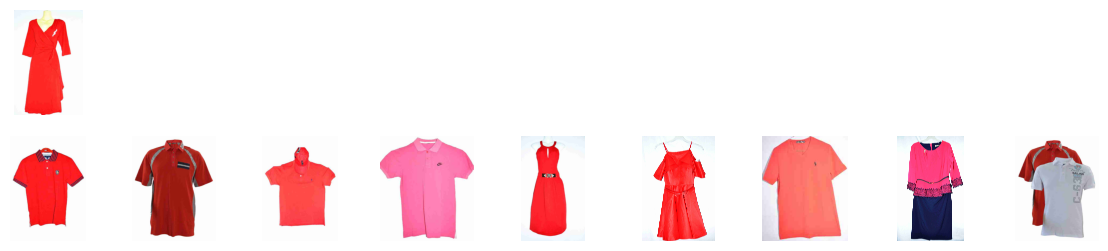

In [10]:
from src.utils import make_recommendations

# recommendation with resnet embeddings
make_recommendations(es=es, item_id=1087, model="resnet")

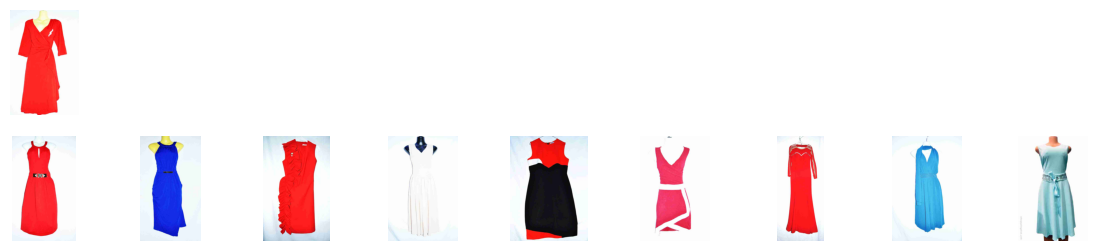

In [11]:
# recommendation with siglip embeddings
make_recommendations(es=es, item_id=1087, model="siglip")

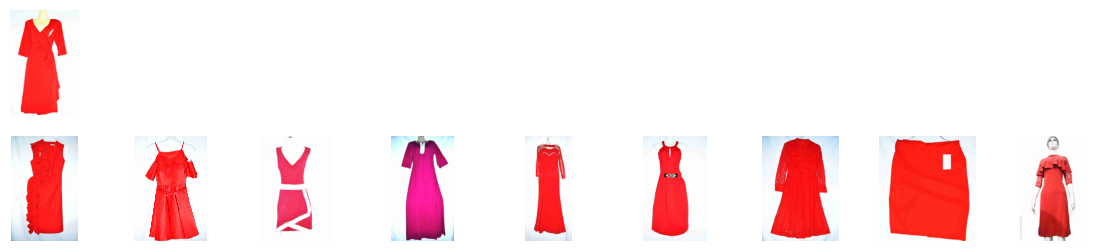

In [12]:
# recommendation with gemini embeddings
make_recommendations(es=es, item_id=1087, model="gemini")

# Building an Image-based Search Engine

In [14]:
from src.elastic import visual_search
from src.utils import display_knn

img_paths = [
    os.path.join(DATASET_DIR, 'img1.jpg'), # woman shoes
    os.path.join(DATASET_DIR, 'img2.png')  # woman afritude
]

img_vectors = gemini_extractor.extract_embeddings(img_paths)

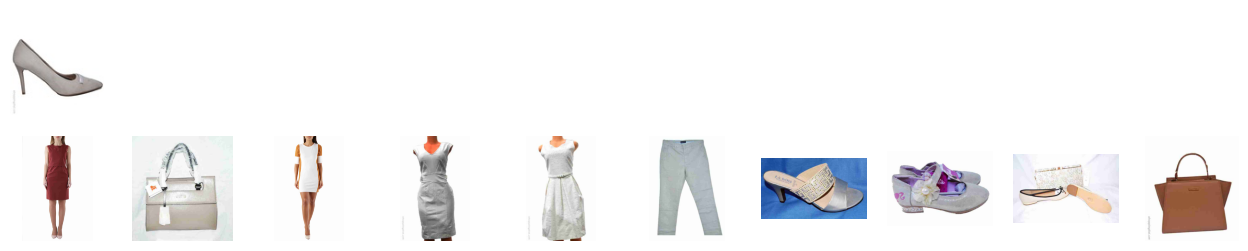

In [15]:
knn_results = visual_search(es=es, src_vector=img_vectors[0], model="gemini")
display_knn(knn_items=knn_results, src_img_path=img_paths[0])

Second example

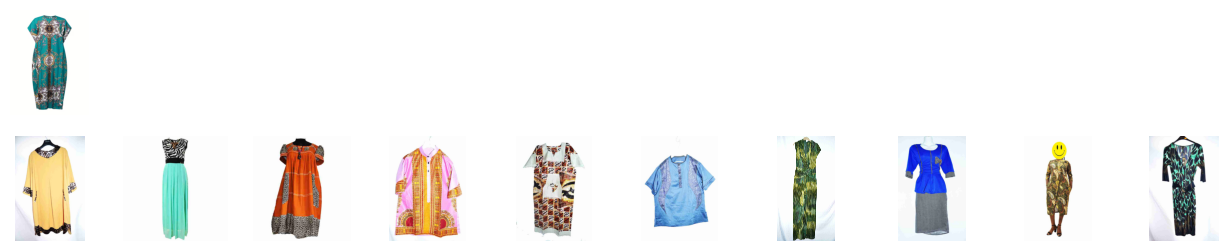

In [17]:
knn2_results = visual_search(es=es, src_vector=img_vectors[1], model="gemini")
display_knn(knn_items=knn2_results, src_img_path=img_paths[1])

### Author
Carmel WENGA, Data & ML Engineer
- [Medium](https://medium.com/@carmelwenga)
- [LinkedIn](https://www.linkedin.com/in/carmel-christian-wenga-871876178/)